In [1]:
import pathlib

import altair as alt
import geopandas as gpd
import laspy
import logging
import numpy as np
import open3d as o3d
import pyproj
import shapely 

import pitchmark
import pitchmark.osm
import pitchmark.lidar

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
logging.basicConfig(level=logging.INFO)

In [3]:
logging.getLogger()

<RootLogger root (INFO)>

In [4]:
logging.warning("abc")
logging.info("def")

INFO:root:def


In [5]:
map_path = pathlib.Path().cwd() / "OpenStreetMap" / "augusta_national" / "map.osm"
handler = pitchmark.osm.GolfHandler()
handler.apply_file(map_path)
fc = handler.feature_collection
augusta_national = pitchmark.Course.from_featurecollection(fc)

In [6]:
geoseries = augusta_national.gdf.geometry
geoseries

168    POLYGON ((-364.377 210.856, -364.295 207.363, ...
222    POLYGON ((-399.804 -688.022, -398.869 -692.801...
158    POLYGON ((-167.382 -395.922, -159.639 -418.350...
138    POLYGON ((-106.194 -302.804, -105.249 -314.509...
135    POLYGON ((-181.484 -183.993, -181.413 -186.310...
                             ...                        
112    POLYGON ((-183.500 -421.879, -177.088 -422.219...
34     POLYGON ((-94.679 -80.650, -94.435 -81.656, -9...
161    POLYGON ((-245.263 -280.750, -230.011 -333.381...
32     POLYGON ((-179.462 -186.079, -179.370 -186.953...
31     POLYGON ((-173.079 -166.866, -173.039 -167.715...
Name: geometry, Length: 204, dtype: geometry

In [7]:
azalea = augusta_national.holes[12]
azalea

Hole(hole_number=13, name='Azalea', path=<LINESTRING (-82.024 33.494, -82.024 33.496, -82.025 33.497, -82.026 33.497)>)

In [8]:
redbud = augusta_national.holes[15]
redbud

Hole(hole_number=16, name='Redbud', path=<LINESTRING (-82.026 33.498, -82.026 33.5)>)

In [9]:
folder = pathlib.Path().cwd() / "USGS_LIDAR"
files = [
    "USGS_LPC_GA_Statewide_2018_B18_DRRA_e1284n1253.laz",
    "USGS_LPC_GA_Statewide_2018_B18_DRRA_e1284n1254.laz",
    "USGS_LPC_GA_Statewide_2018_B18_DRRA_e1285n1253.laz",
    "USGS_LPC_GA_Statewide_2018_B18_DRRA_e1285n1254.laz",
]
paths = [folder / file for file in files]
paths

[WindowsPath('c:/Users/istvan/OneDrive/dev/pitchmark/data-raw/USGS_LIDAR/USGS_LPC_GA_Statewide_2018_B18_DRRA_e1284n1253.laz'),
 WindowsPath('c:/Users/istvan/OneDrive/dev/pitchmark/data-raw/USGS_LIDAR/USGS_LPC_GA_Statewide_2018_B18_DRRA_e1284n1254.laz'),
 WindowsPath('c:/Users/istvan/OneDrive/dev/pitchmark/data-raw/USGS_LIDAR/USGS_LPC_GA_Statewide_2018_B18_DRRA_e1285n1253.laz'),
 WindowsPath('c:/Users/istvan/OneDrive/dev/pitchmark/data-raw/USGS_LIDAR/USGS_LPC_GA_Statewide_2018_B18_DRRA_e1285n1254.laz')]

In [10]:
# las_classes = [
#     pitchmark.lidar.las.LasClassification.unclassified,
#     pitchmark.lidar.las.LasClassification.ground,
# ]
# pitchmark.lidar.las.clip_to_geoseries(
#     paths,
#     geoseries,
#     classification_filter=las_classes,
#     to_file=folder / "augusta_national_unclassified_or_ground.laz",
# )
ground = laspy.read(folder / "augusta_national_ground.laz")

In [11]:
augusta_national.populate_hole_meshes(folder / "augusta_national_ground.laz")

INFO:root:Populating hole meshes from c:\Users\istvan\OneDrive\dev\pitchmark\data-raw\USGS_LIDAR\augusta_national_ground.laz:
INFO:root:Preparing hole 1...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:Preparing hole 2...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:Preparing hole 3...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:Preparing hole 4...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:Preparing hole 5...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:Preparing hole 6...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:

In [12]:
tee = list(augusta_national.transformer_to_local.itransform(azalea.path.coords))[0]

In [13]:
azalea.mesh["yards_east"] = (azalea.mesh["x"] - tee[0])
azalea.mesh["yards_north"] = (azalea.mesh["y"] - tee[1]) 
azalea.mesh["yards_from_tee"] = np.sqrt(
    azalea.mesh["yards_east"]** 2 + azalea.mesh["yards_north"] ** 2
)
azalea.mesh

,geometry,x,y,z,normal_x,normal_y,normal_z,angle,grade,yards_east,yards_north,yards_from_tee
0,"POLYGON Z ((-624.417 -623.448 62.446, -624.622...",-624.612037,-630.986969,62.577649,-0.144275,-0.013542,-0.989445,0.093585,0.144910,-256.077324,380.035686,458.260536
1,"POLYGON Z ((-624.417 -623.448 62.446, -624.797...",-624.592529,-627.290113,62.490708,0.587409,-0.017413,0.809103,-0.029635,0.587667,-256.057816,383.732542,461.320137
2,"POLYGON Z ((-624.417 -623.448 62.446, -624.563...",-624.382258,-626.816195,62.399079,0.313506,-0.009997,0.949534,-0.031878,0.313666,-255.847545,384.206460,461.597844
3,"POLYGON Z ((-624.417 -623.448 62.446, -624.166...",-623.953100,-626.447753,62.334263,0.093201,-0.022681,0.995389,-0.238713,0.095921,-255.418387,384.574901,461.666987
4,"POLYGON Z ((-624.417 -623.448 62.446, -623.276...",-623.366948,-625.727487,62.342029,-0.015242,-0.052598,0.998499,1.288735,0.054762,-254.832235,385.295168,461.943540
...,...,...,...,...,...,...,...,...,...,...,...,...
73682,"POLYGON Z ((-350.242 -943.795 49.644, -349.534...",-349.937363,-943.230159,49.476972,-0.064262,0.315409,0.946778,-1.369805,0.321889,18.597350,67.792496,70.297112
73683,"POLYGON Z ((-308.865 -788.929 56.274, -308.387...",-308.422622,-789.119434,56.233715,0.055157,-0.084076,0.994932,-0.990193,0.100554,60.112091,221.903220,229.901072
73684,"POLYGON Z ((-366.536 -1000.181 54.139, -367.51...",-367.235999,-1000.436067,54.138051,-0.007428,0.016049,0.999844,-1.137344,0.017684,1.298714,10.586588,10.665950
73685,"POLYGON Z ((-288.293 -891.006 49.961, -286.686...",-287.531423,-890.245632,49.974590,0.000024,-0.017564,0.999846,-1.569443,0.017564,81.003290,120.777023,145.425658


In [14]:
azalea.mesh

,geometry,x,y,z,normal_x,normal_y,normal_z,angle,grade,yards_east,yards_north,yards_from_tee
0,"POLYGON Z ((-624.417 -623.448 62.446, -624.622...",-624.612037,-630.986969,62.577649,-0.144275,-0.013542,-0.989445,0.093585,0.144910,-256.077324,380.035686,458.260536
1,"POLYGON Z ((-624.417 -623.448 62.446, -624.797...",-624.592529,-627.290113,62.490708,0.587409,-0.017413,0.809103,-0.029635,0.587667,-256.057816,383.732542,461.320137
2,"POLYGON Z ((-624.417 -623.448 62.446, -624.563...",-624.382258,-626.816195,62.399079,0.313506,-0.009997,0.949534,-0.031878,0.313666,-255.847545,384.206460,461.597844
3,"POLYGON Z ((-624.417 -623.448 62.446, -624.166...",-623.953100,-626.447753,62.334263,0.093201,-0.022681,0.995389,-0.238713,0.095921,-255.418387,384.574901,461.666987
4,"POLYGON Z ((-624.417 -623.448 62.446, -623.276...",-623.366948,-625.727487,62.342029,-0.015242,-0.052598,0.998499,1.288735,0.054762,-254.832235,385.295168,461.943540
...,...,...,...,...,...,...,...,...,...,...,...,...
73682,"POLYGON Z ((-350.242 -943.795 49.644, -349.534...",-349.937363,-943.230159,49.476972,-0.064262,0.315409,0.946778,-1.369805,0.321889,18.597350,67.792496,70.297112
73683,"POLYGON Z ((-308.865 -788.929 56.274, -308.387...",-308.422622,-789.119434,56.233715,0.055157,-0.084076,0.994932,-0.990193,0.100554,60.112091,221.903220,229.901072
73684,"POLYGON Z ((-366.536 -1000.181 54.139, -367.51...",-367.235999,-1000.436067,54.138051,-0.007428,0.016049,0.999844,-1.137344,0.017684,1.298714,10.586588,10.665950
73685,"POLYGON Z ((-288.293 -891.006 49.961, -286.686...",-287.531423,-890.245632,49.974590,0.000024,-0.017564,0.999846,-1.569443,0.017564,81.003290,120.777023,145.425658


In [15]:
layout = pitchmark.plotting.chart_course(azalea.gdf)

In [16]:
alt.Chart(azalea.mesh.iloc[::50]).mark_circle().encode(
    longitude="x",
    latitude="y",
    color="z",
    tooltip=["yards_east", "yards_north", "yards_from_tee", "z"],
).project(
    type="identity",
    reflectY=True
)

alt.Chart(...)

In [17]:
azalea.mesh[azalea.mesh["grade"] <= 0.1].iloc[::20]

,geometry,x,y,z,normal_x,normal_y,normal_z,angle,grade,yards_east,yards_north,yards_from_tee
3,"POLYGON Z ((-624.417 -623.448 62.446, -624.166...",-623.953100,-626.447753,62.334263,0.093201,-0.022681,0.995389,-0.238713,0.095921,-255.418387,384.574901,461.666987
73,"POLYGON Z ((-513.690 -596.147 60.747, -514.823...",-514.077187,-596.358575,60.732619,-0.022353,-0.026560,0.999397,0.871197,0.034714,-145.542474,414.664079,439.464345
99,"POLYGON Z ((-409.766 -629.789 62.192, -411.276...",-410.088990,-630.236972,62.164670,-0.000226,-0.060544,0.998166,1.567060,0.060544,-41.554278,380.785683,383.046334
126,"POLYGON Z ((-304.443 -774.942 57.114, -305.404...",-304.999601,-774.080816,57.135287,0.035614,-0.002130,0.999363,-0.059744,0.035678,63.535112,236.941839,245.312343
182,"POLYGON Z ((-623.276 -627.606 62.244, -622.011...",-622.564743,-626.780257,62.303958,-0.037938,-0.039275,0.998508,0.802718,0.054606,-254.030030,384.242397,460.622922
...,...,...,...,...,...,...,...,...,...,...,...,...
73561,"POLYGON Z ((-386.469 -759.663 53.533, -385.538...",-386.488302,-759.045997,53.562710,-0.058171,-0.049306,0.997088,0.703100,0.076256,-17.953589,251.976658,252.615454
73582,"POLYGON Z ((-581.775 -637.026 58.987, -582.810...",-582.597740,-636.114164,59.014919,0.079828,0.041665,0.995937,0.481044,0.090048,-214.063027,374.908490,431.716754
73613,"POLYGON Z ((-364.333 -920.024 49.696, -365.243...",-365.015606,-919.841626,49.683883,-0.014790,0.011190,0.999828,-0.647691,0.018546,3.519107,91.181028,91.248913
73648,"POLYGON Z ((-313.754 -808.391 54.866, -311.288...",-312.401483,-806.957374,54.984440,-0.054269,-0.031398,0.998033,0.524507,0.062698,56.133230,204.065281,211.644935


In [35]:
azalea.mesh["slope_heading"] = np.degrees(
    np.arctan2(azalea.mesh["normal_x"], azalea.mesh["normal_y"])
)
azalea.mesh["slope_heading"] = np.where(
    azalea.mesh["slope_heading"] < 0,
    azalea.mesh["slope_heading"] + 360,
    azalea.mesh["slope_heading"]
)
azalea.mesh


,geometry,x,y,z,normal_x,normal_y,normal_z,angle,grade,yards_east,yards_north,yards_from_tee,slope_heading
0,"POLYGON Z ((-624.417 -623.448 62.446, -624.622...",-624.612037,-630.986969,62.577649,-0.144275,-0.013542,-0.989445,0.093585,0.144910,-256.077324,380.035686,458.260536,264.637950
1,"POLYGON Z ((-624.417 -623.448 62.446, -624.797...",-624.592529,-627.290113,62.490708,0.587409,-0.017413,0.809103,-0.029635,0.587667,-256.057816,383.732542,461.320137,91.697940
2,"POLYGON Z ((-624.417 -623.448 62.446, -624.563...",-624.382258,-626.816195,62.399079,0.313506,-0.009997,0.949534,-0.031878,0.313666,-255.847545,384.206460,461.597844,91.826501
3,"POLYGON Z ((-624.417 -623.448 62.446, -624.166...",-623.953100,-626.447753,62.334263,0.093201,-0.022681,0.995389,-0.238713,0.095921,-255.418387,384.574901,461.666987,103.677275
4,"POLYGON Z ((-624.417 -623.448 62.446, -623.276...",-623.366948,-625.727487,62.342029,-0.015242,-0.052598,0.998499,1.288735,0.054762,-254.832235,385.295168,461.943540,196.160916
...,...,...,...,...,...,...,...,...,...,...,...,...,...
73682,"POLYGON Z ((-350.242 -943.795 49.644, -349.534...",-349.937363,-943.230159,49.476972,-0.064262,0.315409,0.946778,-1.369805,0.321889,18.597350,67.792496,70.297112,348.484018
73683,"POLYGON Z ((-308.865 -788.929 56.274, -308.387...",-308.422622,-789.119434,56.233715,0.055157,-0.084076,0.994932,-0.990193,0.100554,60.112091,221.903220,229.901072,146.733881
73684,"POLYGON Z ((-366.536 -1000.181 54.139, -367.51...",-367.235999,-1000.436067,54.138051,-0.007428,0.016049,0.999844,-1.137344,0.017684,1.298714,10.586588,10.665950,335.164997
73685,"POLYGON Z ((-288.293 -891.006 49.961, -286.686...",-287.531423,-890.245632,49.974590,0.000024,-0.017564,0.999846,-1.569443,0.017564,81.003290,120.777023,145.425658,179.922434


In [19]:
green_or_short_grass = azalea.gdf[
        (azalea.gdf.ground_cover == "green")
        | (azalea.gdf.ground_cover == "short_grass")
    ].unary_union
shapely.prepare(green_or_short_grass)
selected_mesh = azalea.mesh[azalea.mesh.within(green_or_short_grass)]

In [20]:
selector = alt.selection_single(on="mouseover", nearest=True)
inclines = (
    alt.Chart(selected_mesh.iloc[::20])
    .mark_point(
        shape="wedge",
        filled=True,
        color="lightgray",
    )
    .encode(
        longitude="x",
        latitude="y",
        color=alt.condition(selector, alt.value("black"), alt.value("lightgray")),
        angle="slope_heading",
        size=alt.Size("grade", scale=alt.Scale(domain=[0, 0.1])),
        tooltip=["yards_east", "yards_north", "yards_from_tee", "z", "slope_heading", "grade"],
    )
    .add_selection(selector)
    .project(
        type="identity",
        reflectY=True,
    )
    .properties(
        width=800,
        height=800,
    )
)


In [21]:
(layout + inclines)

alt.LayerChart(...)

In [37]:
redbud = augusta_national.holes[15]
redbud

Hole(hole_number=16, name='Redbud', path=<LINESTRING (-82.026 33.498, -82.026 33.5)>)

In [49]:
redbud_flag = augusta_national.transformer_to_local.transform(*redbud.path.coords[-1])
redbud_flag

(-671.6084493783727, -338.06800716476437)

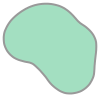

In [77]:
redbud_green = redbud.gdf[
    redbud.gdf.contains(shapely.Point(redbud_flag))
    & (redbud.gdf["course_area"] == "putting_green")
].unary_union
redbud_green_surround = redbud_green.buffer(10.0)
shapely.prepare(redbud_green_surround)
redbud_green_surround


In [72]:
surround_features = pitchmark.plotting.chart_course(redbud.gdf.clip(redbud_green_surround))

In [81]:
redbud.mesh["slope_heading"] = np.degrees(
    np.arctan2(redbud.mesh["normal_x"], redbud.mesh["normal_y"])
)
redbud.mesh["slope_heading"] = np.where(
    redbud.mesh["slope_heading"] < 0,
    redbud.mesh["slope_heading"] + 360,
    redbud.mesh["slope_heading"]
)
redbud.mesh

,geometry,x,y,z,normal_x,normal_y,normal_z,angle,grade,slope_heading
0,"POLYGON Z ((-722.370 -324.131 64.727, -723.880...",-723.129066,-326.857397,64.694034,-0.416098,0.126681,-0.900452,-0.295534,0.434955,286.932878
1,"POLYGON Z ((-722.370 -324.131 64.727, -723.137...",-722.590648,-325.580908,64.727810,0.011487,-0.001116,0.999933,-0.096876,0.011541,95.550613
2,"POLYGON Z ((-722.370 -324.131 64.727, -722.265...",-721.603203,-324.812762,64.698826,0.036846,0.000310,0.999321,0.008403,0.036848,89.518532
3,"POLYGON Z ((-722.370 -324.131 64.727, -720.174...",-721.041185,-323.835273,64.690599,0.034348,-0.031720,0.998906,-0.745645,0.046754,132.722335
4,"POLYGON Z ((-722.370 -324.131 64.727, -720.579...",-721.589892,-323.186172,64.724229,0.027229,-0.019660,0.999436,-0.625346,0.033585,125.829677
...,...,...,...,...,...,...,...,...,...,...
22263,"POLYGON Z ((-595.573 -498.149 63.364, -595.955...",-596.007130,-497.790848,63.358087,-0.017726,-0.005113,0.999830,0.280840,0.018448,253.909054
22264,"POLYGON Z ((-596.494 -497.968 63.349, -595.955...",-596.571818,-497.293812,63.355609,-0.009243,-0.011535,0.999891,0.895259,0.014781,218.705415
22265,"POLYGON Z ((-597.267 -496.658 63.357, -596.974...",-597.360890,-495.569101,63.371441,0.000897,-0.013626,0.999907,-1.505082,0.013655,176.234853
22266,"POLYGON Z ((-596.513 -487.339 63.361, -594.856...",-595.458883,-487.231551,63.343911,0.014824,0.014778,0.999781,0.783859,0.020932,45.088160


In [103]:
selected_mesh = redbud.mesh[redbud.mesh.within(redbud_green)]
selector = alt.selection_single(on="mouseover", nearest=True)
inclines = (
    alt.Chart(selected_mesh)
    .mark_point(
        shape="wedge",
        filled=True,
        color="lightgray",
    )
    .encode(
        longitude="x",
        latitude="y",
        color=alt.condition(
            selector,
            alt.value("red"),
            alt.Color("grade:Q", scale=alt.Scale(domain=[0, 0.12], scheme="greys")),
        ),
        angle="slope_heading",
        size="grade",
        tooltip=["z", "slope_heading", "grade"],
    )
    .add_selection(selector)
    .project(
        type="identity",
        reflectY=True,
    )
    .properties(
        width=800,
        height=800,
    )
)


In [104]:
surround_features + inclines

alt.LayerChart(...)

In [105]:
surround_features

alt.Chart(...)